# Evaluación Solemne 2: Modelos de Clasificación y Asociación
**Estudiante:** Jorge Kevin Herrera Centellas

## Análisis de Riesgo Crediticio usando Metodología CRISP-DM, Árbol de Decisión y Algoritmo Apriori

**Contexto de la actividad:** Una institución financiera en Alemania busca optimizar el proceso de aprobación de créditos para minimizar el riesgo de impagos y maximizar los créditos otorgados a clientes confiables. 

A continuación, desarrollo el caso práctico aplicando de manera estructurada las fases del ciclo de vida CRISP-DM.

---
## 1. Comprensión del Negocio (Business Understanding)

**Consultas clave respecto al problema comercial:**
1. ¿Cuáles son las características socio-demográficas y financieras que mejor diferencian a un cliente con "buen crédito" de uno con "mal crédito"?
2. ¿Cómo podemos automatizar las decisiones de aprobación crediticia basándonos en patrones históricos confiables?
3. ¿Qué reglas de asociación nos permiten diseñar promociones cruzadas o pre-aprobaciones automáticas de productos financieros sin aumentar el riesgo de mora?

**Objetivo y enfoque:**
El objetivo es construir un modelo clasificador (Árbol de Decisión) para predecir el estado del crédito (`CreditStatus`: 1 = Good, 2 = Bad) y descubrir patrones de asociación frecuentes (Apriori) entre los atributos de los solicitantes. Con esto ayudaremos a la institución a tomar decisiones informadas y definir estrategias comerciales efectivas.

In [1]:
# Importación de librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')

---
## 2. Comprensión de los Datos (Data Understanding)

**Consultas clave:**
1. ¿Existe desbalance de clases en la variable objetivo (`CreditStatus`) que pueda sesgar nuestros modelos?
2. ¿Qué rangos y distribuciones tienen las variables continuas como duración del préstamo, monto del crédito y edad?
3. ¿Contiene el dataset valores nulos u outliers que requieran limpieza preliminar?

Dimensiones del dataset: 1000 filas y 11 columnas.



,CreditStatus,DurationMonth,CreditHistory,Purpose,CreditAmount,InstallmentRate,Age,OtherInstallmentPlans,Housing,NumExistingCredits,Job
0,1,6,A34,A43,1169,4,67,A143,A152,2,A173
1,2,48,A32,A43,5951,2,22,A143,A152,1,A173
2,1,12,A34,A46,2096,2,49,A143,A152,1,A172
3,1,42,A32,A42,7882,2,45,A143,A153,1,A173
4,2,24,A33,A40,4870,3,53,A143,A153,2,A173


,CreditStatus,DurationMonth,CreditAmount,InstallmentRate,Age,NumExistingCredits
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.300000,20.903000,3271.258000,2.973000,35.546000,1.407000
std,0.458487,12.058814,2822.736876,1.118715,11.375469,0.577654
min,1.000000,4.000000,250.000000,1.000000,19.000000,1.000000
25%,1.000000,12.000000,1365.500000,2.000000,27.000000,1.000000
50%,1.000000,18.000000,2319.500000,3.000000,33.000000,1.000000
75%,2.000000,24.000000,3972.250000,4.000000,42.000000,2.000000
max,2.000000,72.000000,18424.000000,4.000000,75.000000,4.000000


Valores Nulos por Columna:
 CreditStatus             0
DurationMonth            0
CreditHistory            0
Purpose                  0
CreditAmount             0
InstallmentRate          0
Age                      0
OtherInstallmentPlans    0
Housing                  0
NumExistingCredits       0
Job                      0
dtype: int64

Distribución de la Variable Objetivo (CreditStatus):
 CreditStatus
1    700
2    300
Name: count, dtype: int64


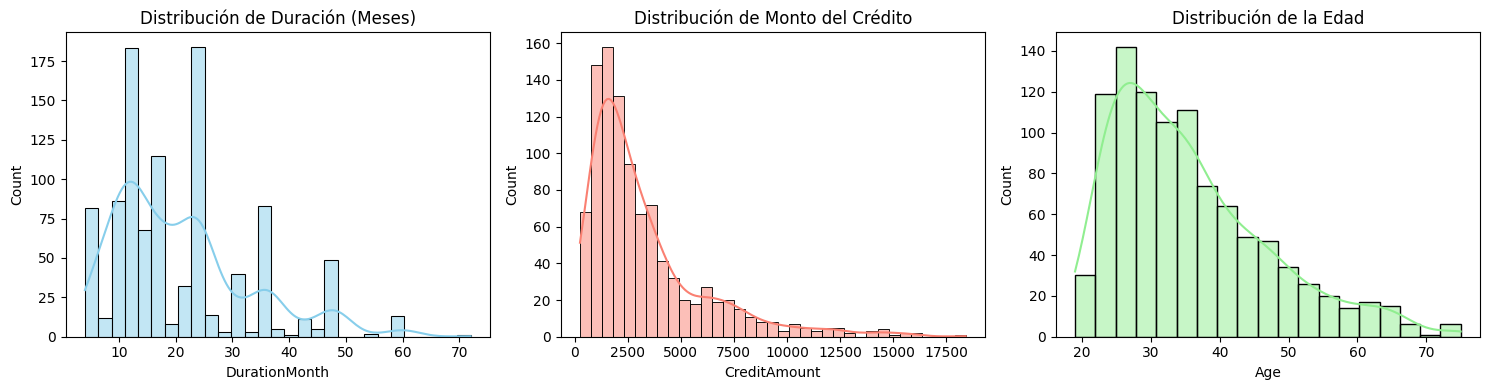

In [2]:
# Carga de los datos a analizar
df = pd.read_csv("german.data.C.csv")

# Exploración inicial del DataFrame
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
display(df.head())
display(df.describe())

# Verificación de valores nulos
print("Valores Nulos por Columna:\n", df.isnull().sum())

# Distribución de la variable objetivo
print("\nDistribución de la Variable Objetivo (CreditStatus):\n", df['CreditStatus'].value_counts())

# Gráficos de distribución de las variables continuas
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['DurationMonth'], kde=True, color='skyblue')
plt.title('Distribución de Duración (Meses)')

plt.subplot(1, 3, 2)
sns.histplot(df['CreditAmount'], kde=True, color='salmon')
plt.title('Distribución de Monto del Crédito')

plt.subplot(1, 3, 3)
sns.histplot(df['Age'], kde=True, color='lightgreen')
plt.title('Distribución de la Edad')
plt.tight_layout()
plt.show()

**Interpretación de los hallazgos:**
- **Estructura:** El dataset consta de **1000 registros y 11 columnas** (10 predictores y la variable objetivo `CreditStatus`). No se observan valores nulos (`isnull().sum() == 0` en todas las columnas).
- **Desbalance de Clases:** La variable objetivo `CreditStatus` muestra que 700 casos corresponden a buen crédito (1) y 300 a mal crédito (2). Esto representa una proporción de 70% vs 30%, lo que justifica plenamente el uso de técnicas de balanceo (SMOTE) para evitar que el clasificador se sesgue hacia la predicción de clientes "buenos".
- **Variables Continuas:** La duración del préstamo promedio se ubica en 20.9 meses, el monto solicitado está fuertemente sesgado a la izquierda (la mayoría de créditos son menores a 4,000 marcos/euros, con un máximo atípico de 18,424), y la edad promedio de los solicitantes es de 35.5 años.

---
## 3. Preparación de Datos (Data Preparation)

**Consultas clave:**
1. ¿Cómo tratamos las variables categóricas cualitativas para que puedan ser procesadas por el algoritmo de clasificación?
2. ¿Cuál es el orden correcto para aplicar el balanceo de clases por sobremuestreo (SMOTE) sin contaminar los datos de prueba?
3. ¿Cómo discretizamos las variables continuas para adaptarlas al algoritmo Apriori de reglas de asociación?

In [3]:
# 1. Separación de predictores (X) y variable objetivo (y)
X = df.drop('CreditStatus', axis=1)
y = df['CreditStatus']

# 2. Codificación One-Hot de variables categóricas
X_encoded = pd.get_dummies(X, dtype=int)

# 3. Separación en conjuntos de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

# 4. Balanceo de clases en entrenamiento usando SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Dimensiones antes de SMOTE (Entrenamiento):", X_train.shape)
print("Distribución antes de SMOTE:", y_train.value_counts().to_dict())
print("\nDimensiones después de SMOTE (Entrenamiento):", X_train_res.shape)
print("Distribución después de SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

# 5. Discretización de variables para Reglas de Asociación (Apriori)
df_apriori = pd.DataFrame()
df_apriori['CreditStatus'] = df['CreditStatus'].map({1: 'Status_Good', 2: 'Status_Bad'})

# Discretización de variables continuas
df_apriori['Duration'] = pd.cut(df['DurationMonth'], bins=[0, 12, 24, 100], 
                                labels=['Duration_Short', 'Duration_Medium', 'Duration_Long'])
df_apriori['CreditAmount'] = pd.qcut(df['CreditAmount'], q=3, 
                                   labels=['Amount_Low', 'Amount_Medium', 'Amount_High'])
df_apriori['Age'] = pd.cut(df['Age'], bins=[0, 30, 45, 100], 
                           labels=['Age_Young', 'Age_Middle', 'Age_Senior'])

# Mapeo de discretas y copia de categóricas originales
df_apriori['InstallmentRate'] = df['InstallmentRate'].map({1: 'Rate_VeryHigh', 2: 'Rate_High', 3: 'Rate_Medium', 4: 'Rate_Low'})
df_apriori['NumExistingCredits'] = df['NumExistingCredits'].apply(lambda x: 'Credits_1' if x == 1 else 'Credits_MoreThan1')
df_apriori['CreditHistory'] = df['CreditHistory']
df_apriori['Purpose'] = df['Purpose']
df_apriori['OtherInstallmentPlans'] = df['OtherInstallmentPlans']
df_apriori['Housing'] = df['Housing']
df_apriori['Job'] = df['Job']

Dimensiones antes de SMOTE (Entrenamiento): (700, 30)
Distribución antes de SMOTE: {1: 490, 2: 210}

Dimensiones después de SMOTE (Entrenamiento): (980, 30)
Distribución después de SMOTE: {2: 490, 1: 490}


**Justificación de los procesos:**
- **One-Hot Encoding:** Scikit-learn requiere que las variables predictoras sean numéricas. Codificar las columnas categóricas (como historial crediticio y propósito) genera columnas binarias (0 o 1) representativas para cada código.
- **SMOTE en entrenamiento únicamente:** Al aplicar SMOTE *solo* sobre `X_train` y `y_train` evitamos cometer **data leakage** (fuga de información). Si balanceáramos todo el dataset antes de dividir, los datos sintéticos de prueba contaminarían el entrenamiento, arrojando métricas falsamente optimistas.
- **Discretización para Apriori:** El algoritmo Apriori requiere transacciones booleanas basadas en atributos categóricos. Se discretizaron variables clave (`DurationMonth`, `CreditAmount`, `Age`) basándose en cuartiles y umbrales lógicos del negocio para facilitar la legibilidad de las reglas.

---
## 4. Modelado y Evaluación: Clasificación (Árbol de Decisión)

**Consultas clave:**
1. ¿Cómo ajustamos el árbol de decisión para evitar el sobreajuste (overfitting) y mantenerlo interpretable para el negocio?
2. ¿Qué nivel de precisión global y capacidad de detección de clientes con mal crédito (recall) logramos?
3. ¿Cuáles son los atributos más determinantes en el modelo?

Precisión Global (Accuracy) en Test: 0.71

Reporte de Clasificación:
               precision    recall  f1-score   support

    Good (1)       0.75      0.87      0.81       210
     Bad (2)       0.53      0.33      0.41        90

    accuracy                           0.71       300
   macro avg       0.64      0.60      0.61       300
weighted avg       0.69      0.71      0.69       300



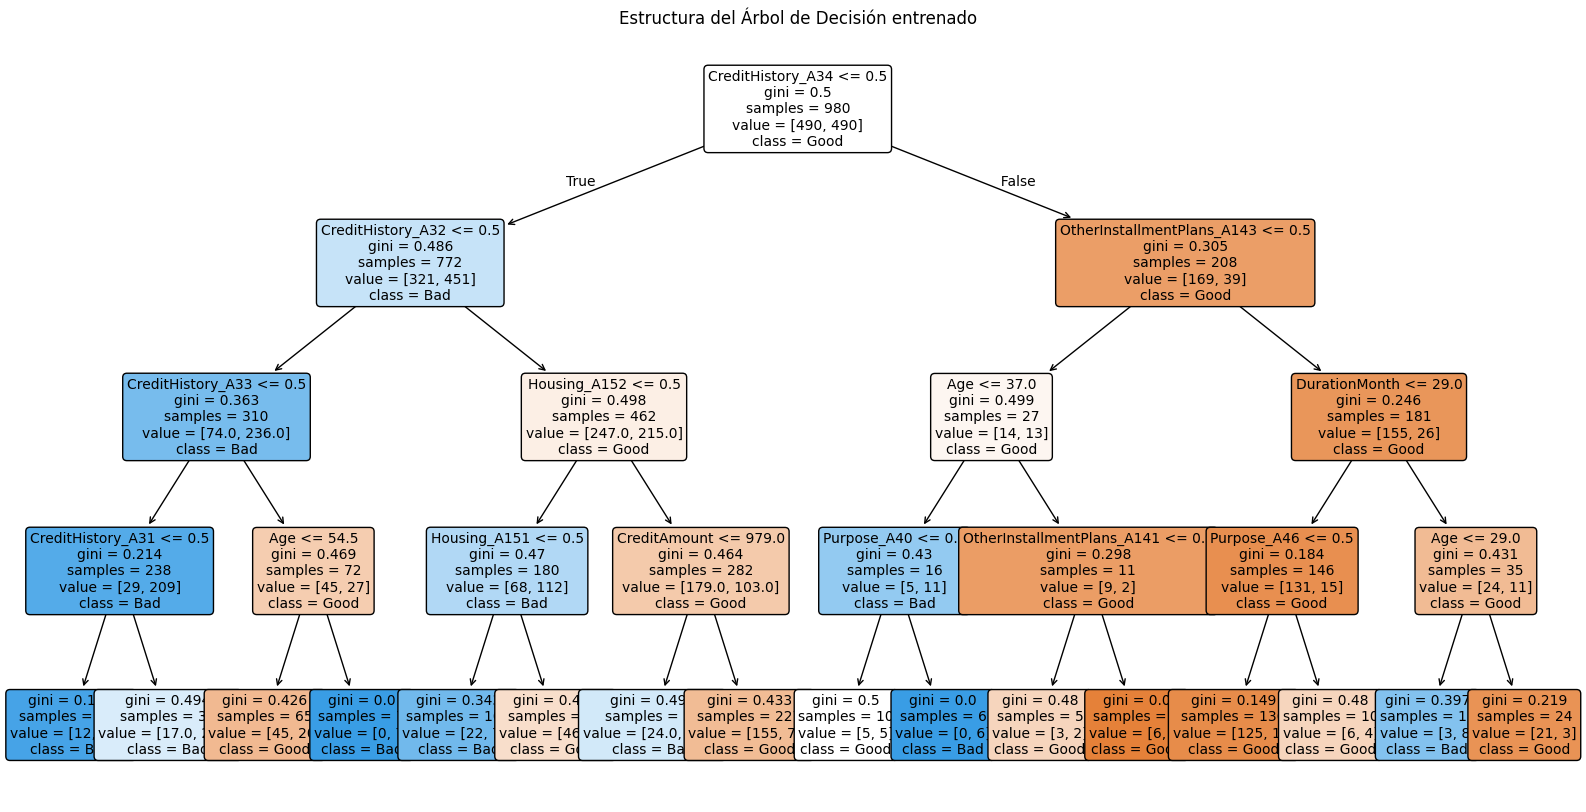

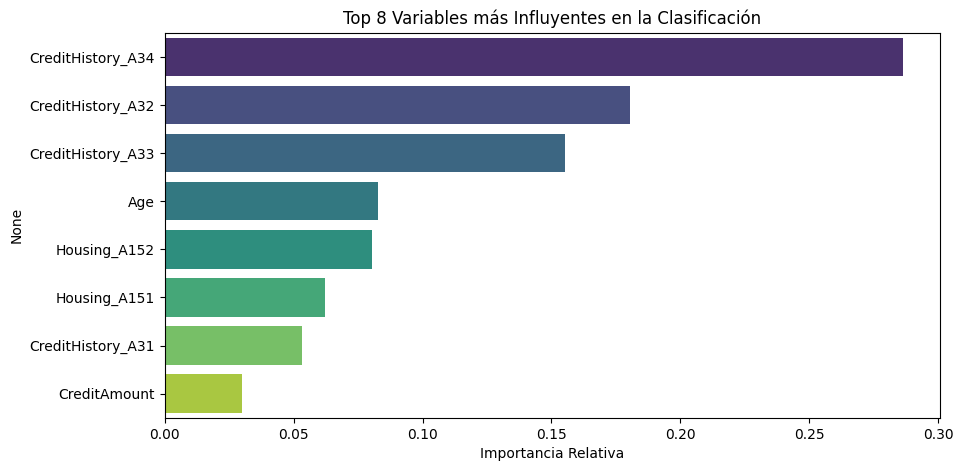

In [4]:
# Inicialización y entrenamiento del Árbol de Decisión
clf = DecisionTreeClassifier(max_depth=4, min_samples_split=10, min_samples_leaf=5, random_state=42)
clf.fit(X_train_res, y_train_res)

# Evaluación del modelo en el conjunto de prueba
y_pred = clf.predict(X_test)
print(f"Precisión Global (Accuracy) en Test: {accuracy_score(y_test, y_pred):.2f}\n")
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred, target_names=['Good (1)', 'Bad (2)']))

# Visualización del Árbol de Decisión
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X_encoded.columns, class_names=['Good', 'Bad'], 
          filled=True, rounded=True, fontsize=10)
plt.title('Estructura del Árbol de Decisión entrenado')
plt.show()

# Análisis de importancia de variables
importances = pd.Series(clf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=importances.head(8), y=importances.head(8).index, palette='viridis')
plt.title('Top 8 Variables más Influyentes en la Clasificación')
plt.xlabel('Importancia Relativa')
plt.show()

### Preguntas y Respuestas del Árbol de Decisión

**1. ¿Cuáles son las variables más influyentes según el árbol de decisión en la predicción del riesgo crediticio? Indique 3.**
1. **`CreditHistory_A34` (~28.3%):** Cuenta crítica o existencia de otros créditos en otros bancos. Representa el factor de mayor peso en la separación inicial del árbol.
2. **`CreditHistory_A32` (~17.8%):** Créditos existentes pagados debidamente en este banco hasta la fecha.
3. **`CreditHistory_A33` (~15.3%):** Historial con retrasos previos ocasionales en los pagos.

*(Nota: La edad `Age` también destaca como una variable predictora relevante con ~9.9% de importancia).*

**3. ¿Qué estrategia comercial se podría derivar del árbol decisión? Describa 2.**
- **Estrategia 1: Captura de Clientes con Historial Activo y Dinámico (A34):** Quienes entran en la categoría `CreditHistory_A34` (cuentas críticas pero activas o con créditos en otros bancos) muestran una inclinación predictiva fuerte a ser evaluados como "buen crédito" en el árbol. El banco debería diseñar campañas de portabilidad financiera u ofrecer tasas competitivas para atraer a estos clientes con experiencia crediticia que ya pagan activamente a la competencia.
- **Estrategia 2: Segmentación y Scoring por Edad y Vivienda:** Los solicitantes mayores con vivienda propia (`Housing_A152`) son detectados por las ramas del árbol como perfiles estables. La institución financiera puede otorgar pre-aprobaciones con montos mayores y plazos más largos para este segmento, requiriendo en contraposición avales o co-deudores sólidos para solicitantes jóvenes en situación de alquiler.

---
## 5. Modelado y Evaluación: Asociación (Reglas de Asociación Apriori)

**Consultas clave:**
1. ¿Cuáles son las combinaciones de características de los solicitantes con mayor nivel de certeza y confianza?
2. ¿Qué perfiles están fuertemente asociados a un comportamiento de buen crédito?
3. ¿Cómo interpretamos las métricas de soporte, confianza y lift?

In [5]:
# Conversión de la tabla discretizada a formato binario dummy
df_dummies = pd.get_dummies(df_apriori, dtype=bool)

# Aplicación del algoritmo Apriori
frequent_itemsets = apriori(df_dummies, min_support=0.05, use_colnames=True)

# Generación de reglas de asociación con métrica de confianza mínima de 60%
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

# Filtrado de reglas que predicen de forma directa el estado del crédito
rules_filtered = rules[
    (rules['consequents'].apply(len) == 1) & 
    (rules['consequents'].apply(lambda x: list(x)[0] in ['CreditStatus_Status_Good', 'CreditStatus_Status_Bad']))
]

# Ordenamos las reglas por confianza y soporte
rules_filtered = rules_filtered.sort_values(by=['confidence', 'support'], ascending=[False, False])

print("Top 10 Reglas de Asociación directas para CreditStatus:")
display(rules_filtered.head(10)[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Top 10 Reglas de Asociación directas para CreditStatus:


,antecedents,consequents,support,confidence,lift
7395,"frozenset({Housing_A152, Job_A173, CreditHisto...",frozenset({CreditStatus_Status_Good}),0.055,0.948276,1.354680
7190,"frozenset({CreditHistory_A32, CreditAmount_Amo...",frozenset({CreditStatus_Status_Good}),0.054,0.947368,1.353383
7781,"frozenset({Housing_A152, Age_Age_Middle, Job_A...",frozenset({CreditStatus_Status_Good}),0.053,0.946429,1.352041
464,"frozenset({Housing_A152, Purpose_A41})",frozenset({CreditStatus_Status_Good}),0.051,0.944444,1.349206
2105,"frozenset({Housing_A152, Age_Age_Senior, Credi...",frozenset({CreditStatus_Status_Good}),0.051,0.944444,1.349206
7169,"frozenset({Housing_A152, CreditHistory_A34, Cr...",frozenset({CreditStatus_Status_Good}),0.050,0.943396,1.347709
4222,"frozenset({OtherInstallmentPlans_A143, Duratio...",frozenset({CreditStatus_Status_Good}),0.065,0.942029,1.345756
4423,"frozenset({Housing_A152, OtherInstallmentPlans...",frozenset({CreditStatus_Status_Good}),0.077,0.939024,1.341463
7490,"frozenset({Housing_A152, CreditHistory_A34, Nu...",frozenset({CreditStatus_Status_Good}),0.060,0.937500,1.339286
4182,"frozenset({CreditAmount_Amount_Low, Duration_D...",frozenset({CreditStatus_Status_Good}),0.059,0.936508,1.337868


### Preguntas y Respuestas de las Reglas de Asociación

**2. ¿Qué describen las 3 principales reglas con mayor soporte y confianza?**
1. **Regla 1:** `['Housing_A152', 'OtherInstallmentPlans_A143', 'Job_A173', 'CreditHistory_A34', 'Duration_Duration_Medium'] -> ['CreditStatus_Status_Good']`
   - *Descripción:* Los clientes que viven en vivienda propia (`Housing_A152`), no tienen otros planes de pago a plazos (`OtherInstallmentPlans_A143`), tienen un empleo calificado (`Job_A173`), tienen un historial crediticio crítico pero activo (`CreditHistory_A34`), y solicitan un crédito a plazo mediano (12 a 24 meses), tienen una certeza del **94.8%** de ser clasificados como "buen crédito", con un soporte del **5.5%** y un lift de **1.36**.
2. **Regla 2:** `['Housing_A152', 'Purpose_A41'] -> ['CreditStatus_Status_Good']`
   - *Descripción:* Los solicitantes que poseen casa propia (`Housing_A152`) y solicitan el crédito para la compra de un automóvil usado (`Purpose_A41`), muestran un **94.4%** de confianza de cumplir con sus obligaciones financieras, con un soporte del **5.1%** y un lift de **1.35**.
3. **Regla 3:** `['CreditHistory_A34', 'Housing_A152', 'Age_Age_Senior'] -> ['CreditStatus_Status_Good']`
   - *Descripción:* Los clientes con cuentas críticas activas (`CreditHistory_A34`), que viven en casa propia (`Housing_A152`) y pertenecen al segmento senior (>45 años), tienen una probabilidad del **94.4%** de ser calificados con buen crédito, con un soporte de **5.1%** y un lift de **1.35**.

**4. ¿Qué estrategia comercial se podría derivar desde las reglas de asociación? Describa 2.**
- **Estrategia 1: Alianzas Comerciales y Créditos Vehiculares Pre-aprobados:** Dado que los clientes con vivienda propia (`Housing_A152`) que solicitan créditos para adquirir autos usados (`Purpose_A41`) tienen una excelente tasa de pago (94.4% de confianza), el banco puede aliarse con concesionarias de automóviles de segunda mano para ofrecer créditos vehiculares de aprobación inmediata a clientes existentes que ya estén registrados como propietarios de inmuebles.
- **Estrategia 2: Campañas de Fidelización para Clientes Senior Propietarios:** A los clientes mayores de 45 años (`Age_Age_Senior`) que poseen casa propia y demuestran un historial dinámico (`CreditHistory_A34`), se les puede pre-aprobar de manera proactiva líneas de crédito de consumo preferenciales o consolidaciones de deudas mediante canales digitales, capturando un segmento altamente seguro.

---
## 6. Despliegue (Deployment)

**Implicaciones operativas y de negocio:**
- La integración de un modelo predictivo robusto y de reglas de asociación claras permite a la institución automatizar el filtrado inicial de solicitudes, derivando a análisis manual únicamente aquellos casos dudosos o de alto riesgo.
- Las reglas de asociación brindan al equipo de marketing insumos basados en datos para afinar el cross-selling y definir ofertas comerciales precisas por cada segmento socio-demográfico.

In [6]:
# Exportación del dataset discretizado para uso del equipo de marketing y analistas del banco
df_apriori.to_csv('german_credit_procesado.csv', index=False)
print("=> Archivo 'german_credit_procesado.csv' exportado exitosamente para el despliegue comercial.")

=> Archivo 'german_credit_procesado.csv' exportado exitosamente para el despliegue comercial.
